In [1]:
!unzip img_align_celeba.zip -d celeba_images

unzip:  cannot find or open img_align_celeba.zip, img_align_celeba.zip.zip or img_align_celeba.zip.ZIP.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Carga y Preparación del Dataset

Usamos el dataset **CelebA**, que contiene más de 200,000 imágenes de caras de famosos con 40 atributos etiquetados por imagen.

Para el entrenamiento seleccionamos una muestra aleatoria de 20,000 imágenes para tener variedad de atributos (gafas, bigote, color de pelo, etc.)

In [4]:
import pandas as pd
import os
import zipfile
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Descomprimir el dataset desde Google Drive
with zipfile.ZipFile('/content/drive/MyDrive/img_align_celeba.zip', 'r') as zip_ref:
    zip_ref.extractall('celeba_images')

# Cargar atributos y seleccionar muestra aleatoria de 20,000 imágenes
df = pd.read_csv('/content/drive/MyDrive/list_attr_celeba.csv')
df_final = df.sample(n=20000, random_state=42).reset_index(drop=True)

print(f"Total de imágenes para entrenar: {len(df_final)}")

Total imágenes: 20000
Total de imágenes para entrenar: 20000


## Dataset y DataLoader

Creamos un Dataset personalizado de PyTorch que carga cada imagen del disco bajo demanda. Aplicamos las siguientes transformaciones:
- **CenterCrop(178)**: recortamos la zona central para eliminar el fondo
- **RandomHorizontalFlip**: aumentación de datos para mejorar la generalización
- **Resize(128)**: redimensionamos a 128x128 para equilibrar calidad y velocidad
- **ToTensor**: convertimos a tensor normalizado entre [0, 1]

In [6]:
class CelebADataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]
        path = os.path.join('celeba_images', 'img_align_celeba', img_name)
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(128),
    transforms.ToTensor(),
])

dataset = CelebADataset(df_final, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

## Arquitectura: Beta-VAE

Encoder con 5 capas convolucionales (stride=2) que reducen 128x128 → 4x4, produciendo un vector de 4096. Dos capas lineales proyectan a `mu` y `logvar` (dim=128). El decoder invierte el proceso con ConvTranspose2d. El reparametrization trick permite backprop a través del sampleo.

In [7]:
# Importamos torch
from torch import nn

class BetaVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(BetaVAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),    # 128→64
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),   # 64→32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 32→16
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), # 16→8
            nn.ReLU(),
            nn.Conv2d(256, 256, 4, 2, 1), # 8→4
            nn.ReLU(),
            nn.Flatten()                   # → 256*4*4 = 4096
        )

        self.fc_mu         = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar     = nn.Linear(256 * 4 * 4, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 256 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 256, 4, 2, 1), # 4→8
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8→16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16→32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 32→64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 64→128
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x      = self.encoder(x)
        mu     = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z      = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

## Discriminador

Red convolucional que clasifica imágenes como reales o generadas. Usa LeakyReLU en vez de ReLU para evitar el problema de *dying ReLU* (neuronas con la ReLU que reciben siempre valores negativos) y dejan de aprender permanentemente. La salida es un único logit sin sigmoid . Se usa `BCEWithLogitsLoss` en el entrenamiento.

In [8]:
import torch.nn as nn
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 64x64
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),  # 32x32
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), # 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),# 8x8
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 2, 1),  # 4x4
            nn.AdaptiveAvgPool2d(1),      # Escalado
            nn.Flatten()
           )
    def forward(self, x):
        return self.net(x)

## Inicialización y Función de Loss

Se instancian el VAE y el Discriminador con el optimizador de Adam (lr=1e-4).

Para la loss del VAE se combinan tres términos del método ELBO con perceptual loss:
- **MSE**: reconstrucción píxel a píxel
- **Perceptual loss**: comparación en el espacio de features de VGG16 (Red ya entrenada). Penaliza las diferencias perceptuales más que píxel a píxel (las características mas abstractas)
- **KLD**: regulariza el espacio latente para que siga una gaussiana estándar N(0,1) (sin esto el espacio latente es un caos y no se puede hacer aritmética latente)

La fórmula es: `Loss = (MSE + 0.1 * Perceptual + beta * KLD) / batch_size`

VGG16 se usa congelado (solo como extractor de features) y se normaliza con la media y std de ImageNet.

Se han probado lr mas altos y bajos, pero ninguno con mejor loss en el entrenamiento de ambos modelos

In [9]:
import torch.optim as optim
import torch.nn.functional as F
from torchvision.models import vgg16, VGG16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae  = BetaVAE(latent_dim=128).to(device)
disc = Discriminator().to(device)

opt_vae  = optim.Adam(vae.parameters(), lr=1e-4)
opt_disc = optim.Adam(disc.parameters(), lr=1e-4)

vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:16].to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

# Float 32 porque sino luego da error dtype
mean = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 3, 1, 1)

def norm_vgg(x):
    #Float 32 por si acaso
    return (x.float() - mean) / std

def vae_loss_function(recon_x, x, mu, logvar, beta=1):
    mse  = F.mse_loss(recon_x, x, reduction='sum')
    perc = F.mse_loss(vgg(recon_x), vgg(x), reduction='sum')
    kld  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (mse + 0.1 * perc + beta * kld) / x.size(0)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 169MB/s]


In [10]:
import torch.nn.functional as F

## Entrenamiento

**VAE**:  se entrena en cada batch minimizando la loss combinada.

**Discriminador**: se entrena cada 2 batches (if batch % 2 == 0)para no sobrepasar al VAE. Recibe imágenes reales (label=1) y reconstrucciones del VAE (label=0).

**VAE vs Discriminador**: cada 2 batches el VAE también intenta engañar al discriminador (label=1 para sus reconstrucciones), con peso 0.01 para no dominar la loss principal.

Beta sube gradualmente de 0 a 0.02 —> las primeras épocas el VAE aprende a reconstruir libremente, luego se va ordenando el espacio latente.

Se usa `GradScaler` con mixed precision (float16) para aprovechar al máximo la GPU.

Tiempo total de entrenamiento -> 30 minutos con la GPU T4 de collab

In [12]:
scaler_vae  = torch.amp.GradScaler('cuda')
scaler_disc = torch.amp.GradScaler('cuda')
epochs = 40

for epoch in range(epochs):
    vae.train()
    disc.train()
    beta = min(0.02, 0.005 * epoch)

    loss_vae_total  = 0
    loss_disc_total = 0

    for batch_idx, data in enumerate(dataloader):
        data        = data.to(device)
        batch_size  = data.size(0)
        real_labels = torch.ones(batch_size,  1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        with torch.amp.autocast('cuda'):
            recon, mu, logvar = vae(data)
            loss_vae = vae_loss_function(recon, data, mu, logvar)

        opt_vae.zero_grad()
        scaler_vae.scale(loss_vae).backward()
        scaler_vae.step(opt_vae)
        scaler_vae.update()

        if batch_idx % 2 == 0:
            with torch.amp.autocast('cuda'):
                recon, mu, logvar = vae(data)
                loss_disc = (
                    F.binary_cross_entropy_with_logits(disc(data),            real_labels) +
                    F.binary_cross_entropy_with_logits(disc(recon.detach()),  fake_labels)
                )
            opt_disc.zero_grad()
            scaler_disc.scale(loss_disc).backward()
            scaler_disc.step(opt_disc)
            scaler_disc.update()

            with torch.amp.autocast('cuda'):
                recon, mu, logvar = vae(data)
                loss_vae_gan = 0.01 * F.binary_cross_entropy_with_logits(disc(recon), real_labels)
            opt_vae.zero_grad()
            scaler_vae.scale(loss_vae_gan).backward()
            scaler_vae.step(opt_vae)
            scaler_vae.update()

            loss_disc_total += loss_disc.item()

        loss_vae_total += loss_vae.item()

    print(f"Época {epoch+1:02d}/{epochs} | beta={beta:.3f} | "
          f"VAE: {loss_vae_total/len(dataloader):.4f} | "
          f"Disc: {loss_disc_total/(len(dataloader)//10 + 1):.4f}")

print("¡Entrenamiento finalizado!")

Época 01/40 | beta=0.000 | VAE: 96755.2340 | Disc: 1.4010
Época 02/40 | beta=0.005 | VAE: 90752.3681 | Disc: 0.1300
Época 03/40 | beta=0.010 | VAE: 87659.6534 | Disc: 0.0517
Época 04/40 | beta=0.015 | VAE: 85194.0491 | Disc: 0.0148
Época 05/40 | beta=0.020 | VAE: 82770.0291 | Disc: 0.0033
Época 06/40 | beta=0.020 | VAE: 80598.1371 | Disc: 0.0049
Época 07/40 | beta=0.020 | VAE: 78741.6229 | Disc: 0.0035
Época 08/40 | beta=0.020 | VAE: 76956.1472 | Disc: 0.4117
Época 09/40 | beta=0.020 | VAE: 75348.0332 | Disc: 0.0197
Época 10/40 | beta=0.020 | VAE: 73898.3246 | Disc: 0.0185
Época 11/40 | beta=0.020 | VAE: 72566.6860 | Disc: 0.0192
Época 12/40 | beta=0.020 | VAE: 71338.1718 | Disc: 0.0115
Época 13/40 | beta=0.020 | VAE: 70169.5423 | Disc: 0.0098
Época 14/40 | beta=0.020 | VAE: 69112.3077 | Disc: 0.0039
Época 15/40 | beta=0.020 | VAE: 68103.0353 | Disc: 0.0031
Época 16/40 | beta=0.020 | VAE: 67163.0180 | Disc: 0.0034
Época 17/40 | beta=0.020 | VAE: 66283.2493 | Disc: 0.0023
Época 18/40 | 

## Diagnóstico del Espacio Latente

Comprobamos que el encoder está produciendo vectores distintos para cada cara. Si la varianza fuera cercana a 0 significaría que el modelo está en colapso (genera siempre la misma imagen).

In [13]:
# Diagnóstico: ¿el encoder está produciendo vectores distintos para cada cara?
vae.eval()
mus = []
with torch.inference_mode():
    for i in range(20):
        img = dataset[i].unsqueeze(0).to(device)
        mu  = vae.fc_mu(vae.encoder(img))
        mus.append(mu.cpu())

mus = torch.stack(mus).squeeze()

print("Varianza media entre caras:", mus.var(dim=0).mean().item())
print("Primeras 5 filas de mu (cada fila = una cara):")
print(mus[:5, :8])  # primeras 8 dimensiones de las 5 primeras caras

Varianza media entre caras: 1.5443894863128662
Primeras 5 filas de mu (cada fila = una cara):
tensor([[ 1.1472, -2.4769,  1.0953, -1.2066, -0.2727,  0.1563, -1.2191,  1.2879],
        [ 1.6656,  1.1741,  1.8704, -0.5191,  1.8488,  1.6296, -2.8813, -2.6345],
        [-0.2549, -0.4817, -0.4459,  0.6570,  0.4953,  0.1809, -0.9746, -0.1212],
        [-2.1924, -4.2109,  0.7887, -1.1978,  2.5705, -2.2387,  0.2320, -0.2592],
        [ 0.9582,  0.2167,  0.3111, -0.0356,  1.2013,  2.8226, -1.5674,  1.0951]])


Test superado, se generan vectores distintos y la varianza es no nula

In [14]:
import matplotlib.pyplot as plt
import numpy as np


## Visualización de Reconstrucciones

Comparamos imágenes originales con sus reconstrucciones. El modelo mantiene la estructura general de la cara, orientación y rasgos principales. Que salgan borrosas es una limitación conocida de los VAEs (priorizan la media del espacio latente sobre los detalles finos).

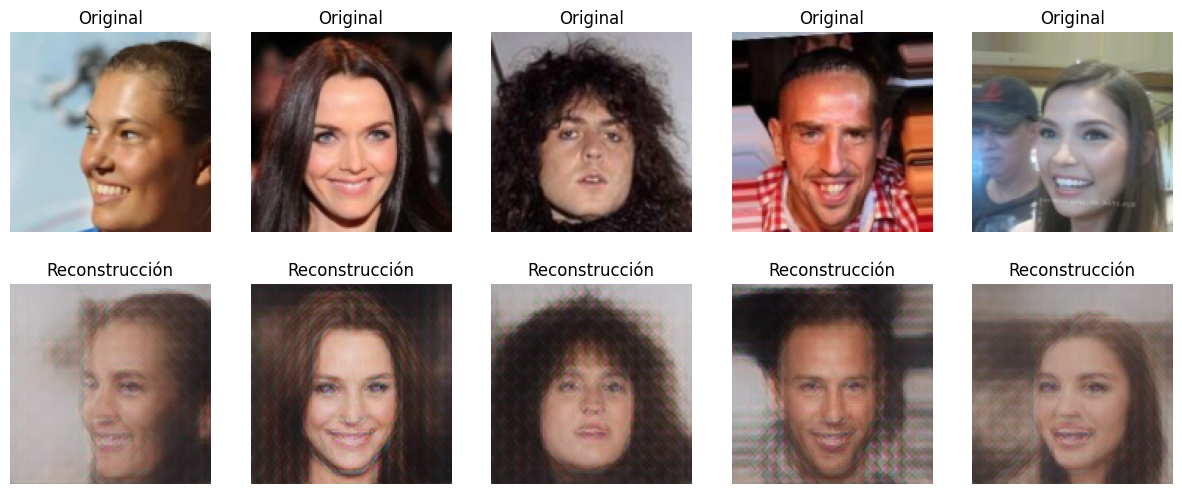

In [15]:
def visualize_reconstruction(n=5):
    vae.eval()
    plt.figure(figsize=(15, 6))
    for i in range(n):
        img = dataset[np.random.randint(len(dataset))].unsqueeze(0).to(device)

        with torch.inference_mode():
            recon, _, _ = vae(img)

        plt.subplot(2, n, i + 1)
        plt.imshow(img.cpu().squeeze().permute(1, 2, 0))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon.cpu().squeeze().permute(1, 2, 0).clamp(0, 1))
        plt.title("Reconstrucción")
        plt.axis("off")
    plt.show()

visualize_reconstruction()

Las reconstrucciones preservan correctamente la identidad, orientación y rasgos generales de cada cara. La pérdida de nitidez es inherente a la arquitectura VAE y se podría reducir con más epochs o una arquitectura más grande.

## Aritmética en el Espacio Latente

Para cada atributo (gafas, bigote, flequillo...) calculamos un **vector de dirección** en el espacio latente:

`v_atributo = mean(mu | atributo=1) - mean(mu | atributo=-1)`

La idea es que la diferencia entre la media de los vectores latentes de caras CON el atributo y SIN él apunta en la dirección del espacio latente que representa ese atributo. Sumando ese vector escalado a cualquier cara podemos añadirle el atributo.

In [16]:
def get_attribute_vector(attr_name, n_samples=1000):
    vae.eval()
    pos_latents = []
    neg_latents = []

    print(f"Calculando vector para: {attr_name}...")
    with torch.inference_mode():
        for imgs in dataloader:
            imgs = imgs.to(device)
            mus = vae.fc_mu(vae.encoder(imgs))

            for j, mu in enumerate(mus):
                idx = len(pos_latents) + len(neg_latents)
                if idx >= len(df_final):
                    break
                val = df_final.iloc[idx][attr_name]
                if val == 1 and len(pos_latents) < n_samples:
                    pos_latents.append(mu.unsqueeze(0))
                elif val == -1 and len(neg_latents) < n_samples:
                    neg_latents.append(mu.unsqueeze(0))

            if len(pos_latents) == n_samples and len(neg_latents) == n_samples:
                break

    vec_pos = torch.mean(torch.cat(pos_latents), dim=0, keepdim=True)
    vec_neg = torch.mean(torch.cat(neg_latents), dim=0, keepdim=True)
    return vec_pos - vec_neg

Calculando vector para: Eyeglasses...
Calculando vector para: Bangs...
Calculando vector para: Mustache...
Calculando vector para: Bags_Under_Eyes...
Calculando vector para: Blond_Hair...


## Test de Atributos

Aplicamos el vector de atributo sobre caras aleatorias sin ese atributo. El parámetro `alpha` controla la intensidad de la transformación.

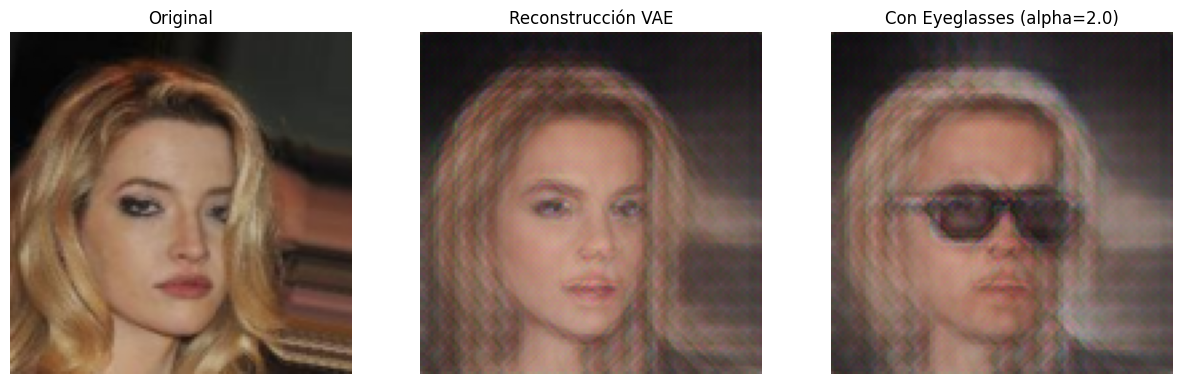

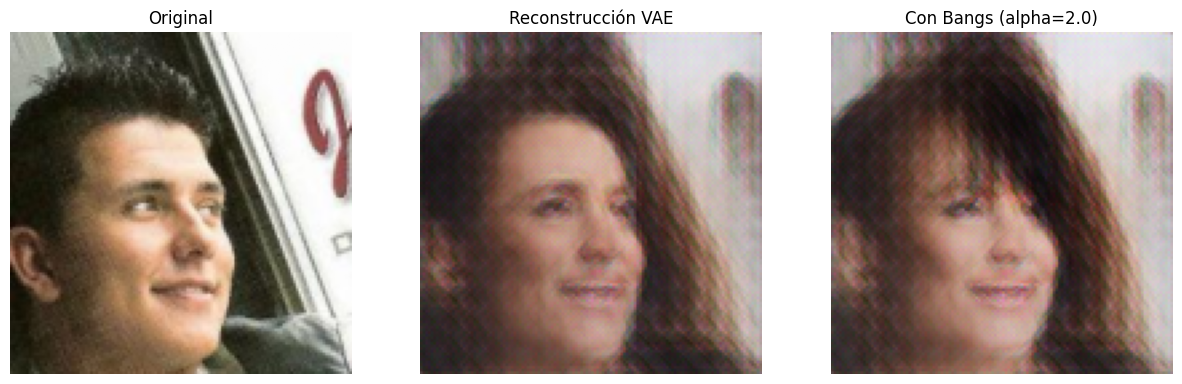

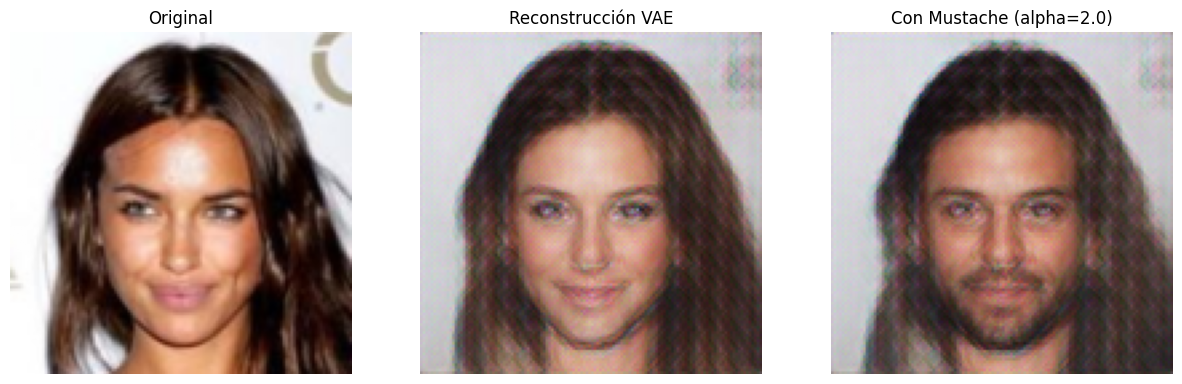

In [19]:
def test_random_face(attr_vector, atr, alpha=1.0):
    vae.eval()
    indices       = df_final[df_final[atr] == -1].index.tolist()
    idx_aleatorio = np.random.choice(indices)
    img_original  = dataset[idx_aleatorio].unsqueeze(0).to(device)

    with torch.inference_mode():
        mu = vae.fc_mu(vae.encoder(img_original))
        recon_normal = vae.decoder(vae.decoder_input(mu))
        mu_modified  = mu + alpha * attr_vector  # usa attr_vector directamente
        recon_mod    = vae.decoder(vae.decoder_input(mu_modified))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original.cpu().squeeze().permute(1, 2, 0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(recon_normal.cpu().squeeze().permute(1, 2, 0).clamp(0, 1))
    plt.title("Reconstrucción VAE")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(recon_mod.cpu().squeeze().permute(1, 2, 0).clamp(0, 1))
    plt.title(f"Con {atr} (alpha={alpha})")
    plt.axis('off')

    plt.show()

    ## AHORA TESTEAMOS
test_random_face(v_glasses,  atr='Eyeglasses', alpha=2.0)
test_random_face(v_bangs,    atr='Bangs',      alpha=2.0)
test_random_face(v_mustache, atr='Mustache',   alpha=2.0)

Los resultados son desiguales según el atributo. Las gafas, por ejemplo, funcionan bien (son un atributo visual muy localizado y con contraste claro). Los bangs y el bigote funcionan peor, ya que es un atributo más sutil y con menos ejemplos positivos en el dataset, lo que produce un vector de dirección menos preciso.

## Interpolación de distintos estados de atributo

Mostramos la transición gradual aplicando el vector de atributo con alphas crecientes. Permite visualizar cómo el espacio latente codifica el atributo.

Generando transición para la imagen índice: 8926...


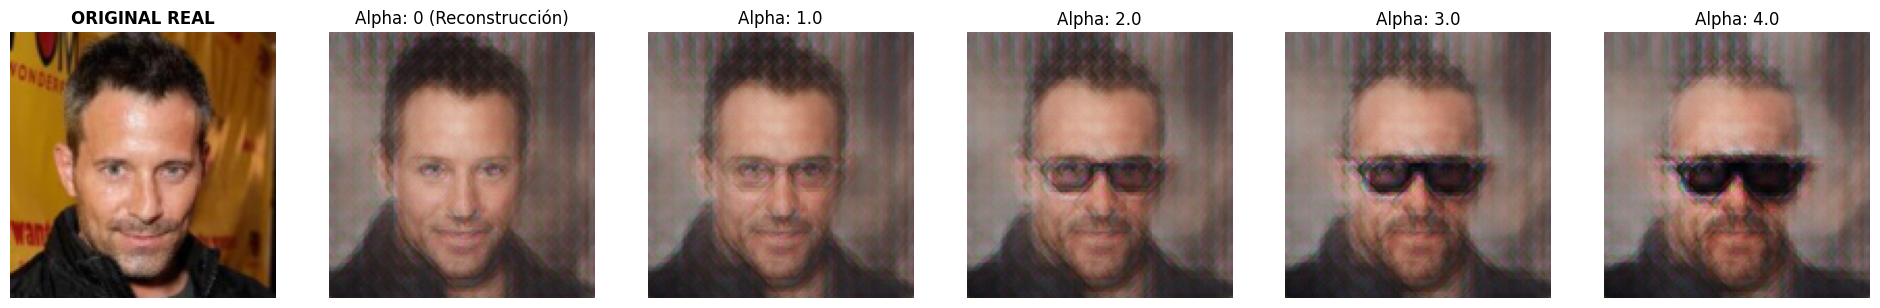

In [18]:
def test_interpolation_con_original(model, dataset, attr_vector, atr='Blond_Hair'):
    model.eval()

    # 1. Elegimos una persona aleatoria sin gafas del dataset filtrado
    indices_sin_gafas = df_final[df_final[atr] == -1].index.tolist()
    idx = np.random.choice(indices_sin_gafas)
    img_tensor = dataset[idx].unsqueeze(0).to(device)

    # 2. Obtenemos su vector latente base (mu)
    with torch.inference_mode():
        mu = model.fc_mu(model.encoder(img_tensor))

    # 3. Preparamos la figura para mostrar 6 pasos (Original + 5 Alphas)
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    alphas = [0, 1.0, 2.0, 3.0, 4.0] # Intensidad progresiva

    print(f"Generando transición para la imagen índice: {idx}...")

    # --- IMAGEN 0: La Original Real ---
    axes[0].imshow(dataset[idx].permute(1, 2, 0))
    axes[0].set_title("ORIGINAL REAL", fontweight='bold')
    axes[0].axis('off')

    # --- RESTO: Reconstrucción e interpolación ---
    for i, a in enumerate(alphas):
        with torch.inference_mode():
            # Aritmética latente progresiva
            z_mod = mu + a * attr_vector
            img_mod = model.decoder(model.decoder_input(z_mod))

            # Dibujar en la siguiente posición (i + 1)
            axes[i+1].imshow(img_mod.cpu().squeeze().permute(1, 2, 0))
            if a == 0:
                axes[i+1].set_title("Alpha: 0 (Reconstrucción)")
            else:
                axes[i+1].set_title(f"Alpha: {a}")
            axes[i+1].axis('off')

    plt.show()

# --- EJECUCIÓN ---
test_interpolation_con_original(vae, dataset, v_glasses, atr='Eyeglasses')

La transición es suave y continua -> las gafas aparecen progresivamente sin romper la identidad de la persona. Esto confirma que el espacio latente está correctamente regularizado y que la dirección aprendida es semánticamente coherente.